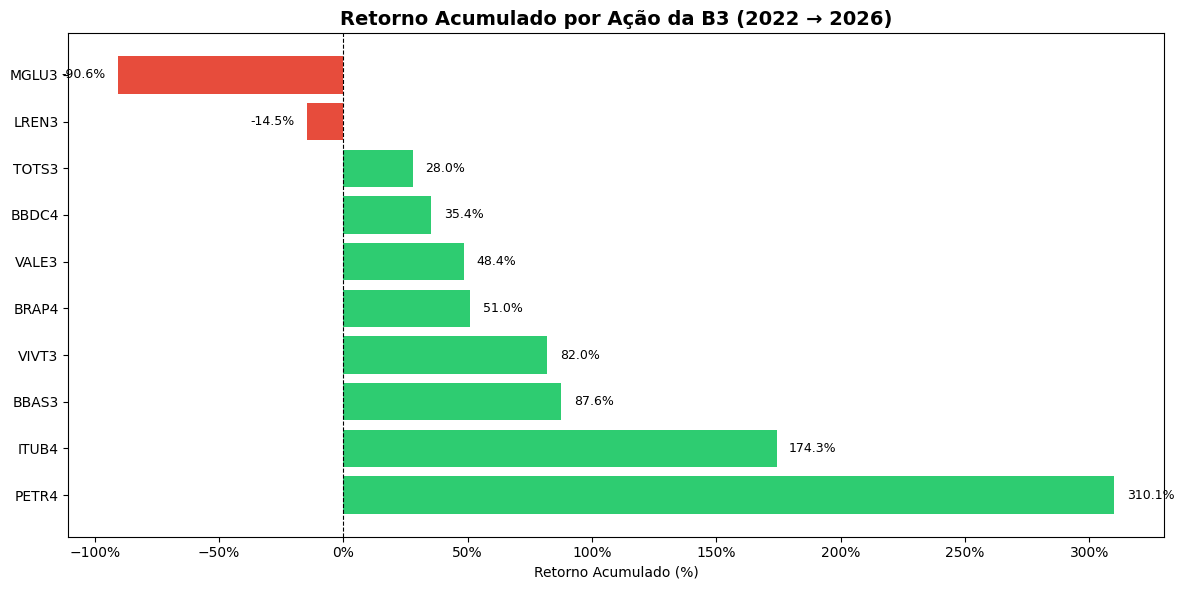

✅ Gráfico 1 salvo!


In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Ler tabelas Gold
gold_retorno = spark.table("b3_pipeline.gold_ranking_retorno").toPandas()
gold_volatilidade = spark.table("b3_pipeline.gold_volatilidade_setor").toPandas()

# ── Gráfico 1: Retorno acumulado por ação ──
fig, ax = plt.subplots(figsize=(12, 6))

cores = ['#2ecc71' if x > 0 else '#e74c3c' for x in gold_retorno['cumulative_return_pct']]

bars = ax.barh(gold_retorno['ticker'], gold_retorno['cumulative_return_pct'], color=cores)

ax.set_xlabel('Retorno Acumulado (%)')
ax.set_title('Retorno Acumulado por Ação da B3 (2022 → 2026)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

for bar, val in zip(bars, gold_retorno['cumulative_return_pct']):
    ax.text(val + (5 if val >= 0 else -5), bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('retorno_acumulado.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 1 salvo!")

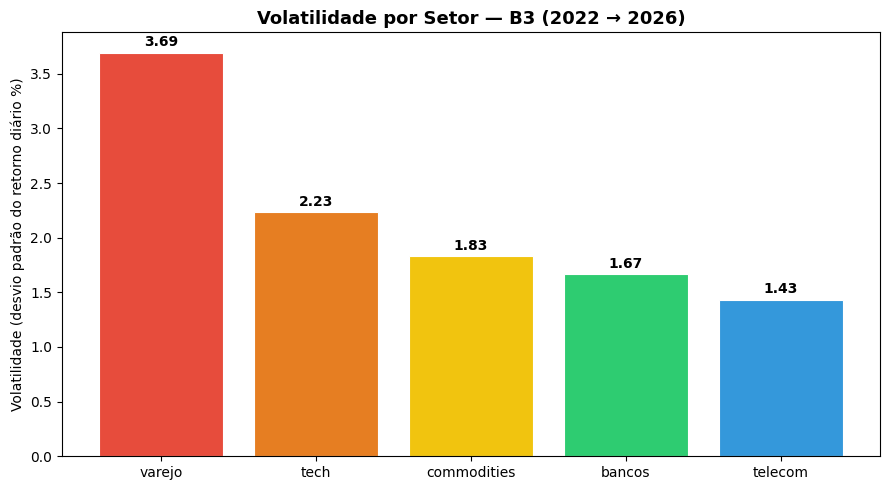

✅ Gráfico 2 salvo!


In [0]:
fig, ax = plt.subplots(figsize=(9, 5))

cores_setor = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

bars = ax.bar(gold_volatilidade['setor'],
              gold_volatilidade['volatilidade'],
              color=cores_setor, edgecolor='white', linewidth=0.8)

ax.set_ylabel('Volatilidade (desvio padrão do retorno diário %)')
ax.set_title('Volatilidade por Setor — B3 (2022 → 2026)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, gold_volatilidade['volatilidade']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('volatilidade_setor.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 salvo!")